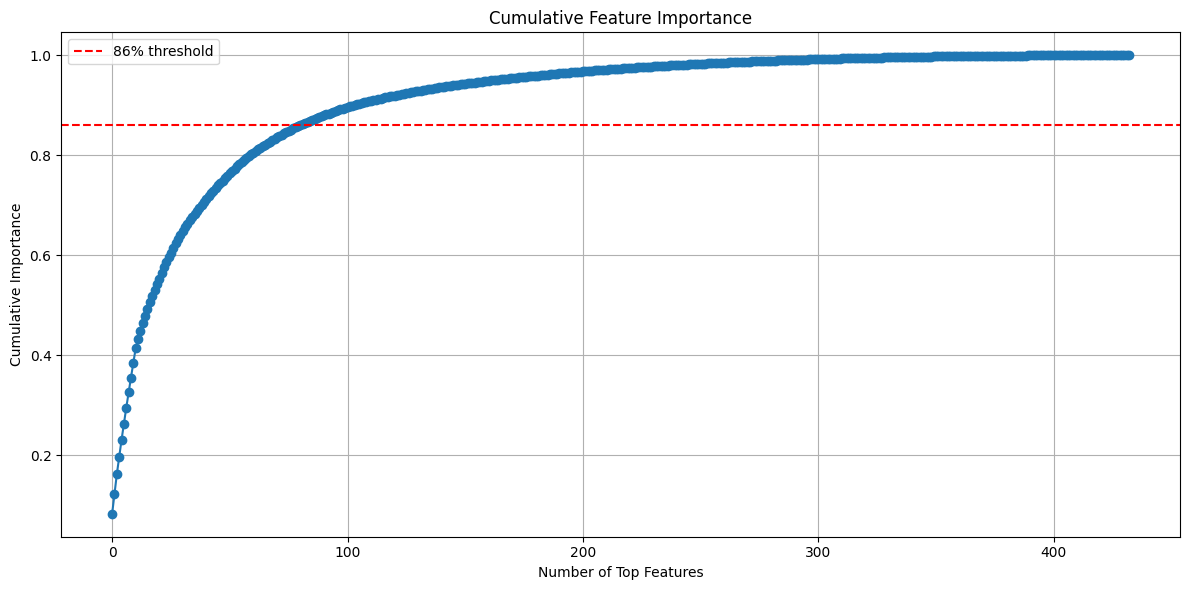

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# Using 86% as the threshold
threshold_1 = 86

# Assuming you've loaded and sorted the feature_importance_df as below:
feature_importance_df = pd.read_csv("feature_importance/lgbm_feature_importance_target_encoded.csv")
feature_importance_df = feature_importance_df.sort_values(by="avg_importance", ascending=False)

# Compute cumulative importance
feature_importance_df["cumulative_importance"] = feature_importance_df["avg_importance"].cumsum() / feature_importance_df["avg_importance"].sum()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(range(len(feature_importance_df)), feature_importance_df["cumulative_importance"], marker='o')
plt.axhline(y=threshold_1 / 100, color='r', linestyle='--', label=f'{threshold_1}% threshold')
plt.xlabel("Number of Top Features")
plt.ylabel("Cumulative Importance")
plt.title("Cumulative Feature Importance")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
# Normalize and compute cumulative importance
feature_importance_df["cumulative_importance"] = feature_importance_df["avg_importance"].cumsum() / feature_importance_df["avg_importance"].sum()

# 86% of total importance
selected_features = feature_importance_df[feature_importance_df["cumulative_importance"] <= (threshold_1 / 100)]["feature"].tolist()

print(f"Selected {len(selected_features)} features covering {threshold_1}% of total importance.")

Selected 80 features covering 86% of total importance.


In [20]:
import pickle

# Load train_dataset 
train_data = pd.read_csv('datasets/train_dataset.csv')

# Separate features and target
X = train_data.drop(['isFraud'], axis=1)
y = train_data['isFraud']

# Subset with selected features
X = X[selected_features].copy()

# Load the 10-fold indices
with open("10_fold_indices.pkl", "rb") as f:
    splits = pickle.load(f)

print(f"Loaded {len(splits)} folds.")

Loaded 10 folds.


In [21]:
import numpy as np
import lightgbm as lgb
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.model_selection import StratifiedKFold
from category_encoders import TargetEncoder
import os

# -------------------- LightGBM Parameters --------------------
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'verbosity': -1,
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'random_state': 42
}

# -------------------- Setup --------------------
auc_scores = []
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
feature_importance_df = pd.DataFrame()

os.makedirs('models/lightgbm_reduced', exist_ok=True)
os.makedirs('feature_importance_reduced', exist_ok=True)

categorical_cols = X.select_dtypes(include='object').columns.tolist()

# -------------------- Cross-Validation Loop --------------------
for fold, (train_idx, val_idx) in enumerate(splits, 1):
    print(f"\n Fold {fold}")

    X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Target Encoding
    encoder = TargetEncoder(cols=categorical_cols)
    X_train[categorical_cols] = encoder.fit_transform(X_train[categorical_cols], y_train)
    X_val[categorical_cols] = encoder.transform(X_val[categorical_cols])

    # LightGBM Dataset
    train_dataset = lgb.Dataset(X_train, label=y_train)
    val_dataset = lgb.Dataset(X_val, label=y_val)

    # Train
    model = lgb.train(
        params=params,
        train_set=train_dataset,
        valid_sets=[val_dataset],
        num_boost_round=5000,
        callbacks=[
            lgb.early_stopping(50),
            lgb.log_evaluation(50)
        ]
    )

    # Predict and Evaluate
    y_val_pred_prob = model.predict(X_val, num_iteration=model.best_iteration)
    y_val_pred = (y_val_pred_prob > 0.5).astype(int)

    auc = roc_auc_score(y_val, y_val_pred_prob)
    accuracy = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, zero_division=0)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)

    # Append metrics
    auc_scores.append(auc)
    accuracy_scores.append(accuracy)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

    print(f" Fold {fold} AUC-ROC : {auc:.4f} | Best Iteration: {model.best_iteration}")
    print(f"   Accuracy : {accuracy:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall   : {recall:.4f}")
    print(f"   F1 Score : {f1:.4f}")

    # Save model
    model.save_model(f'models/lightgbm_reduced/fold_{fold}_2.txt')

    # Feature importance
    fold_importance = pd.DataFrame({
        'feature': model.feature_name(),
        f'fold_{fold}': model.feature_importance(importance_type='gain')
    })
    if feature_importance_df.empty:
        feature_importance_df = fold_importance
    else:
        feature_importance_df = feature_importance_df.merge(fold_importance, on='feature')

# -------------------- Final Summary --------------------
feature_importance_df['avg_importance'] = feature_importance_df.drop('feature', axis=1).mean(axis=1)
feature_importance_df.sort_values(by='avg_importance', ascending=False, inplace=True)
feature_importance_df.to_csv('feature_importance_reduced/lgbm_feature_importance_target_encoded_2.csv', index=False)

# Final metrics summary
print("\n Cross-Validation Results (LightGBM)")
for i in range(len(auc_scores)):
    print(f"Fold {i+1}: AUC={auc_scores[i]:.4f} | Acc={accuracy_scores[i]:.4f} | Prec={precision_scores[i]:.4f} | Recall={recall_scores[i]:.4f} | F1={f1_scores[i]:.4f}")

print("\n Final Averages on 86% Feature Importance:")
print(f"AUC-ROC : {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
print(f"Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Precision: {np.mean(precision_scores):.4f}")
print(f"Recall   : {np.mean(recall_scores):.4f}")
print(f"F1 Score : {np.mean(f1_scores):.4f}")



 Fold 1
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.897379
[100]	valid_0's auc: 0.918949
[150]	valid_0's auc: 0.928037
[200]	valid_0's auc: 0.932617
[250]	valid_0's auc: 0.936003
[300]	valid_0's auc: 0.938936
[350]	valid_0's auc: 0.941038
[400]	valid_0's auc: 0.943356
[450]	valid_0's auc: 0.94468
[500]	valid_0's auc: 0.946358
[550]	valid_0's auc: 0.948207
[600]	valid_0's auc: 0.950296
[650]	valid_0's auc: 0.951532
[700]	valid_0's auc: 0.952809
[750]	valid_0's auc: 0.953803
[800]	valid_0's auc: 0.954545
[850]	valid_0's auc: 0.95512
[900]	valid_0's auc: 0.956245
[950]	valid_0's auc: 0.957047
[1000]	valid_0's auc: 0.957455
[1050]	valid_0's auc: 0.958034
[1100]	valid_0's auc: 0.958386
[1150]	valid_0's auc: 0.958974
[1200]	valid_0's auc: 0.959445
[1250]	valid_0's auc: 0.959988
[1300]	valid_0's auc: 0.960512
[1350]	valid_0's auc: 0.96113
[1400]	valid_0's auc: 0.961575
[1450]	valid_0's auc: 0.961881
[1500]	valid_0's auc: 0.962276
[1550]	valid_0's auc: 0